<a href="https://colab.research.google.com/github/KML0505/CxC-Datathon/blob/projects/CxC_TouchBistro_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q gdown
!gdown --id 1Ocv7PPDX9H8Q_-8W-l2ozTFEkSFnD4ZY -O data.zip
!mkdir -p /content/contents
!unzip -o data.zip -d /content/contents
import os
pd.set_option('display.max_columns', None)

for root, dirs, files in os.walk("/content/contents"):
    for file in files:
        file_path = os.path.join(root, file)
        if file.lower().endswith('.csv'):
            df = pd.read_csv(file_path)

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Ocv7PPDX9H8Q_-8W-l2ozTFEkSFnD4ZY
From (redirected): https://drive.google.com/uc?id=1Ocv7PPDX9H8Q_-8W-l2ozTFEkSFnD4ZY&confirm=t&uuid=fbe0b684-4a58-4dde-8b9c-0227b6eff8f8
To: /content/data.zip
100% 842M/842M [00:16<00:00, 51.4MB/s]
Archive:  data.zip
   creating: /content/contents/CxCData/
  inflating: /content/contents/CxCData/Touchbistro x UW Problem Set.pdf  
  inflating: /content/contents/__MACOSX/CxCData/._Touchbistro x UW Problem Set.pdf  
  inflating: /content/contents/CxCData/venues.csv  
  inflating: /content/contents/__MACOSX/CxCData/._venues.csv  
  inflating: /content/contents/CxCData/dataset_description.pdf  
  inflating: /content/contents/__MACOSX/CxCData/._dataset_description.pdf  
  inflating

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np

In [3]:
bills_df = pd.read_csv('/content/contents/CxCData/bills.csv', nrows = 100000)
venues_df = pd.read_csv('/content/contents/CxCData/venues.csv')

In [4]:
print(bills_df.shape)

(100000, 20)


In [5]:
bills_df.columns.tolist()
venues_df.columns.tolist()

['venue_xref_id', 'concept', 'city', 'country', 'start_of_day_offset']

In [6]:
venues_df

,venue_xref_id,concept,city,country,start_of_day_offset
0,ea74268311cfcc47d2b4c38ef08b9dab0117226a9a99a9...,FAST_FOOD,Albuquerque,US,00:00:00
1,e7cec41c46a9706ba1a702b368be5431913b6dc9c9da49...,FAMILY_DINING,Brooklyn,US,00:00:00
2,e63e79791883b0c4ac71d41eaee727932c13d6a4ec8f78...,FAST_CASUAL,Windsor,CA,00:00:00
3,c100388c9328b30b6bdfbea43f113d367ae9d32b03e84b...,BAR,Burnaby,CA,01:00:00
4,a819ee7f83f27dd3d7f44515e22aca3c26e6704ddd2a9b...,FAMILY_DINING,Tisdale,CA,00:00:00
...,...,...,...,...,...
596,cfd1fa6e8f122e93b1cb02e7b7541749335e7088095f8e...,NaN,Toronto,CA,00:00:00
597,75e7251298f2d62406dbfe1a11011cffdad90b27704687...,NaN,Richardson,US,00:00:00
598,40c38939612f59ad418569e94a075935576bff0449c7f8...,FAST_CASUAL,Guelph,CA,09:00:00
599,2ed5bf26505a6064d09b40bacdb6fccc9665c3de029494...,NaN,Mississauga,CA,00:00:00


In [7]:
first_venue_id = venues_df.iloc[5]['venue_xref_id']

# Find unique cities associated with this venue_xref_id
unique_cities = venues_df.loc[venues_df['venue_xref_id'] == first_venue_id, 'city'].unique()

# Display result
print(unique_cities)

['CALGARY']


In [8]:
df = pd.merge(bills_df, venues_df, on='venue_xref_id', how='left')
df["tip_percentage"] = (
    df["payment_total_tip"].astype(float) / df["bill_total_billed"].replace(0, np.nan)
).fillna(0)
df.drop(['bill_uuid', 'order_uuid', 'waiter_uuid'], axis=1, inplace=True)

In [9]:
df

,bill_paid_at_local,bill_total_billed,bill_total_discount_item_level,bill_total_gratuity,bill_total_net,bill_total_tax,bill_total_voided,business_date,order_duration_seconds,order_seated_at_local,...,payment_amount,payment_count,payment_total_tip,sales_revenue_with_tax,venue_xref_id,concept,city,country,start_of_day_offset,tip_percentage
0,2024-07-01 09:17:01,21.81,0.00,0.0,19.30,2.51,0.0,2024-07-01,46,2024-07-01 09:16:15,...,21.81,1,0.00,21.81,39e5b4830d4d9c14db7368a95b65d5463ea3d095203737...,NaN,Collingwood,CA,00:00:00,0.00000
1,2024-07-01 13:37:00,48.95,0.00,0.0,43.32,5.63,0.0,2024-07-01,288,2024-07-01 13:32:12,...,48.95,1,0.00,48.95,39e5b4830d4d9c14db7368a95b65d5463ea3d095203737...,NaN,Collingwood,CA,00:00:00,0.00000
2,2024-07-01 11:19:32,26.94,0.00,0.0,23.84,3.10,0.0,2024-07-01,135,2024-07-01 11:17:17,...,26.94,1,0.00,26.94,39e5b4830d4d9c14db7368a95b65d5463ea3d095203737...,NaN,Collingwood,CA,00:00:00,0.00000
3,2024-07-01 15:05:59,3.96,0.00,0.0,3.77,0.19,0.0,2024-07-01,48,2024-07-01 15:05:11,...,3.96,1,0.00,3.96,39e5b4830d4d9c14db7368a95b65d5463ea3d095203737...,NaN,Collingwood,CA,00:00:00,0.00000
4,2024-07-01 12:41:00,3.36,0.00,0.0,3.20,0.16,0.0,2024-07-01,103,2024-07-01 12:39:17,...,3.36,1,0.00,3.36,39e5b4830d4d9c14db7368a95b65d5463ea3d095203737...,NaN,Collingwood,CA,00:00:00,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2024-09-20 12:46:47,4.67,0.83,0.0,4.67,0.00,0.0,2024-09-20,54,2024-09-20 12:45:53,...,4.67,1,0.00,4.67,5e8a21ead84851c212c2cae58849de4d37bc0babfcab05...,CAFE,Banff,CA,06:00:00,0.00000
99996,2024-09-20 12:47:05,17.62,2.97,0.0,16.78,0.84,0.0,2024-09-20,94,2024-09-20 12:45:31,...,17.62,1,0.00,17.62,5e8a21ead84851c212c2cae58849de4d37bc0babfcab05...,CAFE,Banff,CA,06:00:00,0.00000
99997,2024-09-20 13:18:16,17.85,3.00,0.0,17.00,0.85,0.0,2024-09-20,85,2024-09-20 13:16:51,...,19.64,1,1.79,17.85,5e8a21ead84851c212c2cae58849de4d37bc0babfcab05...,CAFE,Banff,CA,06:00:00,0.10028
99998,2024-09-20 13:39:58,10.50,0.00,0.0,10.00,0.50,0.0,2024-09-20,76,2024-09-20 13:38:42,...,10.50,1,0.00,10.50,5e8a21ead84851c212c2cae58849de4d37bc0babfcab05...,CAFE,Banff,CA,06:00:00,0.00000


In [10]:
df.columns.tolist()

['bill_paid_at_local',
 'bill_total_billed',
 'bill_total_discount_item_level',
 'bill_total_gratuity',
 'bill_total_net',
 'bill_total_tax',
 'bill_total_voided',
 'business_date',
 'order_duration_seconds',
 'order_seated_at_local',
 'order_closed_at_local',
 'order_take_out_type_label',
 'payment_amount',
 'payment_count',
 'payment_total_tip',
 'sales_revenue_with_tax',
 'venue_xref_id',
 'concept',
 'city',
 'country',
 'start_of_day_offset',
 'tip_percentage']

In [11]:
df_original = df.copy()
df_original.groupby('venue_xref_id').size().sort_values(ascending=False).head(1)

,0
venue_xref_id,
b608ba87efab5acafe841b496ab8536c7a32e4323b5124e6f6acb777db79ad85,10023


In [12]:
venue_to_filter = "b608ba87efab5acafe841b496ab8536c7a32e4323b5124e6f6acb777db79ad85"
df_original[df_original["venue_xref_id"] == venue_to_filter]

,bill_paid_at_local,bill_total_billed,bill_total_discount_item_level,bill_total_gratuity,bill_total_net,bill_total_tax,bill_total_voided,business_date,order_duration_seconds,order_seated_at_local,...,payment_amount,payment_count,payment_total_tip,sales_revenue_with_tax,venue_xref_id,concept,city,country,start_of_day_offset,tip_percentage
24858,2024-07-01 09:57:33,18.07,0.00,0.0,15.99,2.08,0.0,2024-07-01,2071,2024-07-01 09:23:03,...,21.32,1,3.25,18.07,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.179856
24859,2024-07-01 10:20:28,68.35,0.00,0.0,60.49,7.86,0.0,2024-07-01,3095,2024-07-01 09:28:53,...,82.02,1,13.67,68.35,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.200000
24860,2024-07-01 11:32:39,20.89,0.00,0.0,18.49,2.40,0.0,2024-07-01,3718,2024-07-01 10:30:41,...,24.02,1,3.13,20.89,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.149832
24861,2024-07-01 11:46:38,27.10,0.00,0.0,23.98,3.12,0.0,2024-07-01,3558,2024-07-01 10:47:20,...,35.00,1,7.90,27.10,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.291513
24862,2024-07-01 12:05:54,65.46,0.00,0.0,57.93,7.53,0.0,2024-07-01,4330,2024-07-01 10:53:44,...,72.01,1,6.55,65.46,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.100061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68210,2024-11-15 01:55:04,46.33,0.00,0.0,41.00,5.33,0.0,2024-11-14,6840,2024-11-15 00:01:04,...,54.67,1,8.34,46.33,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.180013
78109,2024-11-14 21:07:20,0.00,22.99,0.0,0.00,0.00,0.0,2024-11-14,6256,2024-11-14 19:23:04,...,0.00,0,0.00,0.00,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.000000
78110,2024-11-14 21:35:20,13.56,0.00,0.0,12.00,1.56,0.0,2024-11-14,744,2024-11-14 21:22:56,...,13.56,1,0.00,13.56,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.000000
78111,2024-11-14 22:34:25,75.00,0.00,0.0,66.37,8.63,0.0,2024-11-14,11656,2024-11-14 19:20:09,...,75.00,1,0.00,75.00,b608ba87efab5acafe841b496ab8536c7a32e4323b5124...,FAMILY_DINING,Kingston,CA,08:00:00,0.000000


# Handling missing values

In [13]:
# concept seems to have all of the missing values
df.isnull().sum()
print(df.city.unique())

['Collingwood' 'Honolulu' 'Toronto ' 'Grand Forks' 'San Diego' 'Edmonton'
 'Chatham' 'Calgary' 'East Moline' 'Swansboro' 'Othello' 'Concord  '
 'Orange' 'Kingsville' 'Kingston' 'Medicine Hat' 'Madison' 'Naples'
 'Sudbury' 'Portola ' 'Lunenburg' 'Hinton' 'St. Catharines' 'Hickory'
 'Goodfield' 'Thousand Oaks' 'Blue River' 'Caguas' 'Jackpot' 'Red Deer'
 'Crested Butte' 'Dennis Port' 'Vancouver' 'Ottawa' 'Grand Falls-Windsor'
 'Toronto' 'Fairplay' 'Baltimore' 'Austin' 'Listowel' 'Albany' 'Palatine'
 'St. Andrews By The Sea' 'Banff']


In [14]:
# see what type of data is concept
print(f"concept is of type: {df['concept'].dtype},\nall unique values: \n{df['concept'].unique()}")

concept is of type: object,
all unique values: 
[nan 'BAR' 'FAMILY_DINING' 'CAFE' 'BREWERY' 'FAST_CASUAL' 'HOTEL'
 'FAST_FOOD']


In [15]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import KNNImputer

df_copy = df.copy()
cat_col = "concept"

# use KNN to fill in the missing values of concept, using other features to find the closest value it could be
encoder = OrdinalEncoder()
df_copy[cat_col] = encoder.fit_transform(df_copy[[cat_col]])
categories_mapping = {i: category for i, category in enumerate(encoder.categories_[0])}

# reducing the features used for time sake, likely these are the most important features
feature_cols = ["bill_total_billed",
                "bill_total_discount_item_level",
                "bill_total_gratuity",
                "bill_total_net",
                "sales_revenue_with_tax",
                cat_col]

# Check that all columns exist (this should print an empty set)
print("Missing columns:", set(feature_cols) - set(df_copy.columns))

df_copy = df_copy[feature_cols]

# Check for columns that are completely missing or constant
print("All missing?\n", df_copy.isnull().all())
print("Unique counts:\n", df_copy.nunique())

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=5)
print("Before imputation, df_copy shape:", df_copy.shape)
imputed_array = imputer.fit_transform(df_copy)
print("After imputation, imputed_array shape:", imputed_array.shape)

# If the imputed array has fewer columns than expected, inspect further
if imputed_array.shape[1] != len(feature_cols):
    print("Warning: The imputer returned", imputed_array.shape[1],
          "columns, but", len(feature_cols), "were expected.")

# Reconstruct the DataFrame using the imputer's output columns
# (We use df_copy.columns since that reflects what the imputer used)
df_imputed = pd.DataFrame(imputed_array, columns=df_copy.columns, index=df_copy.index)
print("Unique rounded codes:", df_imputed[cat_col].unique())
print("Category mapping keys:", categories_mapping.keys())


# Round and convert back to categorical for the concept column
if cat_col in df_imputed.columns:
    # Suppose 0..6 are your valid category codes
    df_imputed[cat_col] = df_imputed[cat_col].round().clip(lower=0, upper=6).astype(int)
    df_imputed[cat_col] = df_imputed[cat_col].map(categories_mapping)
    # Assign back to the original DataFrame
    df["concept"] = df_imputed[cat_col]

print(df.isnull().sum())

Missing columns: set()
All missing?
 bill_total_billed                 False
bill_total_discount_item_level    False
bill_total_gratuity               False
bill_total_net                    False
sales_revenue_with_tax            False
concept                           False
dtype: bool
Unique counts:
 bill_total_billed                 13704
bill_total_discount_item_level     1772
bill_total_gratuity                 942
bill_total_net                     9319
sales_revenue_with_tax            13704
concept                               7
dtype: int64
Before imputation, df_copy shape: (100000, 6)
After imputation, imputed_array shape: (100000, 6)
Unique rounded codes: [3.  3.8 2.2 2.  3.2 4.  3.6 3.4 2.4 2.8 2.6 0.2 4.2 1.  1.8 5.6 5.  4.4
 5.2 1.2 1.6 6.  0.4 0.6 0.8 4.6 5.4 1.4 4.8 0. ]
Category mapping keys: dict_keys([0, 1, 2, 3, 4, 5, 6, 7])
bill_paid_at_local                0
bill_total_billed                 0
bill_total_discount_item_level    0
bill_total_gratuity              

In [16]:
print(df.concept)

0        FAMILY_DINING
1          FAST_CASUAL
2          FAST_CASUAL
3                 CAFE
4                 CAFE
             ...      
99995             CAFE
99996             CAFE
99997             CAFE
99998             CAFE
99999             CAFE
Name: concept, Length: 100000, dtype: object


In [17]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = set(df.columns) - set(numeric_cols)

In [18]:
df.dtypes.unique()

array([dtype('O'), dtype('float64'), dtype('int64')], dtype=object)

In [19]:
# let's see the categorical cols
sample_entries = {col: df[col].iloc[0] for col in categorical_cols}
for col, value in sample_entries.items():
    print(f"{col}: {value}\n")

city: Collingwood

bill_paid_at_local: 2024-07-01 09:17:01

order_closed_at_local: 2024-07-01 09:17:01

order_take_out_type_label: dinein

country: CA

business_date: 2024-07-01

start_of_day_offset: 00:00:00

venue_xref_id: 39e5b4830d4d9c14db7368a95b65d5463ea3d09520373723430c03a5a453b5df

concept: FAMILY_DINING

order_seated_at_local: 2024-07-01 09:16:15



In [20]:
# seems like everything is a string or a datetime
# datetime -> convert to unix time and scale the data, since it will be highly scewed
# string -> OHE for low cardinality, we don't seem to have any ordered types so we'll use target encoding for rest with high cardinality

# Extract only the column names as lists
date_cols = ["business_date", "order_closed_at_local", "order_seated_at_local", "start_of_day_offset", "bill_paid_at_local"]
string_cols = list(set(categorical_cols) - set(date_cols))
target_col = "sales_revenue_with_tax"

In [21]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.5 MB/s eta 0:00:00


In [22]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import category_encoders as ce

# ----------------------------
# Custom transformer for date features
# ----------------------------
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self,
                 business_date_col='business_date',
                 order_seated_col='order_seated_at_local',
                 order_closed_col='order_closed_at_local',
                 bill_paid_col='bill_paid_at_local'):
        self.business_date_col = business_date_col
        self.order_seated_col = order_seated_col
        self.order_closed_col = order_closed_col
        self.bill_paid_col = bill_paid_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Convert date columns to datetime
        X[self.business_date_col] = pd.to_datetime(X[self.business_date_col])
        X[self.order_seated_col] = pd.to_datetime(X[self.order_seated_col])
        X[self.order_closed_col] = pd.to_datetime(X[self.order_closed_col])
        X[self.bill_paid_col] = pd.to_datetime(X[self.bill_paid_col])

        # Create new features
        X['business_date_unix'] = X[self.business_date_col].apply(lambda x: x.timestamp())
        X['day_of_week'] = X[self.business_date_col].dt.day_name()
        X['season'] = X[self.business_date_col].dt.month.apply(self.get_season)
        X['order_duration_minutes'] = (X[self.order_closed_col] - X[self.order_seated_col]).dt.total_seconds() / 60.0
        X['time_to_bill_minutes'] = (X[self.bill_paid_col] - X[self.order_seated_col]).dt.total_seconds() / 60.0

        X[self.order_seated_col] = X[self.order_seated_col].dt.round('H')

        # Extract the hour component
        X[self.order_seated_col + '_hour'] = X[self.order_seated_col].dt.hour

        # One-hot encode the hour
        hour_dummies = pd.get_dummies(
            X[self.order_seated_col + '_hour'],
            prefix=self.order_seated_col,
            prefix_sep='-'
        )

        # Concatenate the one-hot columns back to X
        X = pd.concat([X, hour_dummies], axis=1)

        # Drop the original datetime column and the hour column
        X.drop(columns=[self.order_seated_col, self.order_seated_col + '_hour'], inplace=True)

        return X

    @staticmethod
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'

# ----------------------------
# Assume these columns are defined.
# For example, categorical_cols might be defined as:
# ['order_take_out_type_label', 'city', 'country', 'business_date',
#  'order_seated_at_local', 'order_closed_at_local', 'concept', 'bill_paid_at_local',
#  'start_of_day_offset']
# We'll designate the date columns and then derive string_cols.
# ----------------------------
date_cols = ["business_date", "order_seated_at_local", "order_closed_at_local", "bill_paid_at_local"]
string_cols = list(set(categorical_cols) - set(date_cols))

# Split string columns into low and high cardinality groups
low_cardinality_cols = [col for col in string_cols if df[col].nunique() <= 10]
high_cardinality_cols = [col for col in string_cols if df[col].nunique() > 10]

# ----------------------------
# Build pipelines for string columns:
# ----------------------------
low_card_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

high_card_pipeline = Pipeline([
    ('target_enc', ce.TargetEncoder())
])

# ----------------------------
# Build the complete categorical encoding pipeline.
# We set force_int_remainder_cols=False to have the remainder columns returned as names.
# ----------------------------
cat_encoding_pipeline = Pipeline([
    ('date_transform', DateFeatureTransformer()),
    ('col_transform', ColumnTransformer(
        transformers=[
            # Process date-derived features:
            ('unix_scaler', StandardScaler(), ['business_date_unix']),
            ('day_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['day_of_week']),
            ('season_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['season']),
            # Process string columns:
            ('low_card', low_card_pipeline, low_cardinality_cols),
            ('high_card', high_card_pipeline, high_cardinality_cols)
        ],
        remainder='passthrough',
        force_int_remainder_cols=False
    ))
])

# ----------------------------
# Prepare features and target.
# ----------------------------
target_col = "sales_revenue_with_tax"
X = df.drop(columns=[target_col])
y = df[target_col]

# Fit and transform the features. (Note: TargetEncoder requires y.)
encoded_array = cat_encoding_pipeline.fit_transform(X, y)

# ----------------------------
# Helper function to recover output feature names.
# This function goes through each transformer in the ColumnTransformer.
# For remainder columns, we determine which columns were not explicitly transformed.
# ----------------------------
def get_feature_names(col_transformer, input_features):
    """Retrieve feature names from a fitted ColumnTransformer.
       `input_features` should be the columns of the data passed to the ColumnTransformer.
    """
    output_features = []
    # Keep track of columns transformed explicitly.
    transformed_cols = []

    for name, trans, cols in col_transformer.transformers_:
        if trans == 'drop' or trans is None:
            continue

        if name == 'remainder':
            # Remainder columns: use input_features that were not transformed
            remainder_cols = [f for f in input_features if f not in transformed_cols]
            output_features.extend(remainder_cols)
        else:
            # If the transformer is a pipeline, get its last step
            if isinstance(trans, Pipeline):
                last_trans = trans.steps[-1][1]
            else:
                last_trans = trans

            # Try to get feature names from transformers that support it
            if hasattr(last_trans, 'get_feature_names_out'):
                try:
                    # Use the transformer’s fitted feature names if available.
                    names = last_trans.get_feature_names_out()
                except ValueError:
                    # Fall back to using the provided columns.
                    names = last_trans.get_feature_names_out(cols)
                output_features.extend(names)
            else:
                # If the transformer does not support get_feature_names_out,
                # simply use the original column names.
                output_features.extend(cols)
            # Update transformed_cols with the original columns used by this transformer.
            transformed_cols.extend(cols)
    return output_features

# ----------------------------
# To extract the correct remainder names, we need to know the column names of the data
# that was input to the ColumnTransformer.
# We can get that by applying the date transformer to X first.
# ----------------------------
X_transformed = cat_encoding_pipeline.named_steps['date_transform'].transform(X)
input_features = X_transformed.columns.tolist()

# Now retrieve feature names from the ColumnTransformer.
col_transformer = cat_encoding_pipeline.named_steps['col_transform']
feature_names = get_feature_names(col_transformer, input_features)

# ----------------------------
# Convert the final NumPy array back into a DataFrame with proper column names.
# ----------------------------
encoded_df = pd.DataFrame(encoded_array, columns=feature_names)

<ipython-input-22-f056039ac4e3>:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  X[self.order_seated_col] = X[self.order_seated_col].dt.round('H')
<ipython-input-22-f056039ac4e3>:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  X[self.order_seated_col] = X[self.order_seated_col].dt.round('H')


In [23]:
encoded_df = encoded_df.apply(pd.to_numeric, errors='ignore')
y = y.reset_index(drop=True)
df = pd.concat([encoded_df, y], axis=1)
columns = df.columns.tolist()
for col in columns:
    print(f"{col}: {df.loc[1, col]}")


<ipython-input-23-4b4874da253e>:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  encoded_df = encoded_df.apply(pd.to_numeric, errors='ignore')


business_date_unix: -1.6890987201813845
day_of_week_Friday: 0.0
day_of_week_Monday: 1.0
day_of_week_Saturday: 0.0
day_of_week_Sunday: 0.0
day_of_week_Thursday: 0.0
day_of_week_Tuesday: 0.0
day_of_week_Wednesday: 0.0
season_Fall: 0.0
season_Summer: 1.0
order_take_out_type_label_bartab: 0.0
order_take_out_type_label_delivery: 0.0
order_take_out_type_label_dinein: 1.0
order_take_out_type_label_onlineorder: 0.0
order_take_out_type_label_takeout: 0.0
country_CA: 1.0
country_US: 0.0
concept_BAR: 0.0
concept_BREWERY: 0.0
concept_CAFE: 0.0
concept_FAMILY_DINING: 0.0
concept_FAST_CASUAL: 1.0
concept_FAST_FOOD: 0.0
concept_HOTEL: 0.0
city: 15.39851611552951
start_of_day_offset: 39.71631739112555
venue_xref_id: 15.39851611552951
bill_paid_at_local: 1719841020000000000
bill_total_billed: 48.95
bill_total_discount_item_level: 0.0
bill_total_gratuity: 0.0
bill_total_net: 43.32
bill_total_tax: 5.63
bill_total_voided: 0.0
business_date: 1719792000000000000
order_duration_seconds: 288
order_closed_at_l

In [24]:
# drop all of these since they give direct information for our target feature or are redundant after preprocessing
df.drop(['bill_paid_at_local', 'business_date', 'order_closed_at_local', 'bill_total_tax', 'payment_amount', 'bill_total_discount_item_level', 'bill_total_net', 'bill_total_tax', 'bill_total_voided', 'bill_total_billed'], axis=1, inplace=True)

In [25]:
df

,business_date_unix,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,season_Fall,season_Summer,...,order_seated_at_local-15,order_seated_at_local-16,order_seated_at_local-17,order_seated_at_local-18,order_seated_at_local-19,order_seated_at_local-20,order_seated_at_local-21,order_seated_at_local-22,order_seated_at_local-23,sales_revenue_with_tax
0,-1.689099,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,21.81
1,-1.689099,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,48.95
2,-1.689099,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,26.94
3,-1.689099,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,True,False,False,False,False,False,False,False,False,3.96
4,-1.689099,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,3.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.390792,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,4.67
99996,0.390792,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,17.62
99997,0.390792,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,17.85
99998,0.390792,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,10.50


Problem 3 - Forecasting Sales Revenue

In [27]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    y_preds, y_trues = [], []
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch).squeeze()
        y_preds.extend(y_pred.cpu().numpy())
        y_trues.extend(y_batch.numpy())

y_preds = np.array(y_preds).reshape(-1, 1)
y_trues = np.array(y_trues).reshape(-1, 1)

y_preds = np.clip(y_preds, -10, 10)
y_trues = np.clip(y_trues, -10, 10)

y_preds = target_scaler.inverse_transform(y_preds)
y_trues = target_scaler.inverse_transform(y_trues)


y_preds = np.expm1(y_preds)
y_trues = np.expm1(y_trues)

plt.figure(figsize=(12, 6))
plt.plot(y_trues, label="Actual Sales", linestyle="dashed")
plt.plot(y_preds, label="Predicted Sales")
plt.legend()
plt.title("LSTM")
plt.show()


NameError: name 'model' is not defined

In [28]:
print("Max predicted (before expm1):", np.max(y_preds))
print("Min predicted (before expm1):", np.min(y_preds))
print("Max actual (before expm1):", np.max(y_trues))
print("Min actual (before expm1):", np.min(y_trues))


NameError: name 'y_preds' is not defined

In [29]:
# preprocessing venues, scaling them down then upsampling to see how accurate they ar

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

# Define RMSE scorer (lower is better)
rmse_scorer = make_scorer(mean_squared_error, squared=False, greater_is_better=False)

# ============================================================
# 1. Remove Venues with Fewer Than 20 Rows
# ============================================================
venue_counts = df["venue_xref_id"].value_counts()
valid_venues = venue_counts[venue_counts >= 20].index
df = df[df["venue_xref_id"].isin(valid_venues)].copy()

# ============================================================
# 2. SET UP FEATURES & TARGET
# ============================================================
target_col = "sales_revenue_with_tax"

# Retain the venue_xref_id for scaling by copying it to a new column.
df["venue_id_for_scaling"] = df["venue_xref_id"]

# Drop columns not needed in the model.
columns_to_drop = ["venue_xref_id", "bill_total_gratuity", "payment_total_tip"]
for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# ============================================================
# 3. GLOBAL TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69
)

# ============================================================
# 4. DISCARD TEST ROWS WITH NEW VENUES (Not seen in training)
# ============================================================
train_venues = X_train["venue_id_for_scaling"].unique()
test_mask = X_test["venue_id_for_scaling"].isin(train_venues)
X_test = X_test[test_mask].copy()
y_test = y_test[test_mask].copy()

# ============================================================
# 5. FIT SCALERS PER VENUE (on y_train only)
# ============================================================
venue_scalers = {}
y_train_scaled = pd.Series(index=y_train.index, dtype=float)

for venue_id, idx in X_train.groupby("venue_id_for_scaling").groups.items():
    scaler = StandardScaler()
    venue_y = y_train.loc[idx].values.reshape(-1, 1)
    venue_y_scaled = scaler.fit_transform(venue_y).ravel()
    y_train_scaled.loc[idx] = venue_y_scaled
    venue_scalers[venue_id] = scaler

# ============================================================
# 6. GRID SEARCH WITH XGBOOST (Expanded grid to reduce underfitting)
# ============================================================
# Prepare training features by dropping the venue_id_for_scaling column.
X_train_for_model = X_train.drop(columns=["venue_id_for_scaling"], errors="ignore")
X_test_for_model  = X_test.drop(columns=["venue_id_for_scaling"], errors="ignore")

# Expanded parameter grid: deeper trees, more estimators, and a higher learning_rate option.
param_grid = {
    'n_estimators': [600],
    'max_depth': [4],
    'learning_rate': [0.1, 0.15],
    # Optionally add gamma or min_child_weight if needed:
    # 'gamma': [0, 0.1],
    # 'min_child_weight': [1, 3],
}

# First, try to initialize the XGBoost regressor with GPU support.
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='gpu_hist'  # GPU-based hist method
)

# Use GroupKFold with groups defined by venue_id_for_scaling.
groups = X_train["venue_id_for_scaling"]
group_kfold = GroupKFold(n_splits=3)

grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=group_kfold,
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

# Try grid search with GPU settings.
try:
    grid_search.fit(X_train_for_model, y_train_scaled, groups=groups)
except Exception as e:
    print("Grid search with GPU settings failed:", e)
    print("Retrying with CPU settings (tree_method='hist').")
    xgb_reg = xgb.XGBRegressor(
         objective='reg:squarederror',
         random_state=42,
         tree_method='hist'
    )
    grid_search = GridSearchCV(
         estimator=xgb_reg,
         param_grid=param_grid,
         scoring=rmse_scorer,
         cv=group_kfold,
         n_jobs=-1,
         verbose=1
    )
    grid_search.fit(X_train_for_model, y_train_scaled, groups=groups)

best_model = grid_search.best_estimator_
print("=== Best Parameters ===")
print(grid_search.best_params_)

# -----------------------------------------------------------
# Retrain best_model with an evaluation set to monitor RMSE
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split

# Further split the training set for evaluation.
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_for_model, y_train_scaled, test_size=0.2, random_state=42
)

# Set the evaluation metric via set_params.
best_model.set_params(eval_metric="rmse")

# Use callbacks for early stopping.
best_model.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_train_sub, y_train_sub), (X_val, y_val)],
    verbose=True
)

# ============================================================
# 7. PREDICT & INVERSE TRANSFORM ON TEST DATA
# ============================================================
y_pred_scaled = best_model.predict(X_test_for_model)

# For each test row, inverse transform using that row's venue scaler.
y_pred = []
for idx, val_scaled in zip(X_test.index, y_pred_scaled):
    venue_id = X_test.loc[idx, "venue_id_for_scaling"]
    scaler = venue_scalers[venue_id]
    val_original = scaler.inverse_transform(np.array(val_scaled).reshape(-1, 1))[0, 0]
    y_pred.append(val_original)
y_pred = np.array(y_pred)

# ============================================================
# 8. EVALUATE THE MODEL
# ============================================================
r2   = r2_score(y_test, y_pred)

print("=== Final Evaluation ===")
print(f"Test R² Score: {r2:.4f}")

In [30]:
import pandas as pd
import numpy as np
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor, ExtraTreesRegressor,
                              AdaBoostRegressor, StackingRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, make_scorer

# Define RMSE scorer (lower is better)
rmse_scorer = make_scorer(mean_squared_error, squared=False, greater_is_better=False)

# ============================================================
# 1. Remove Venues with Fewer Than 20 Rows
# ============================================================
venue_counts = df["venue_xref_id"].value_counts()
valid_venues = venue_counts[venue_counts >= 20].index
df = df[df["venue_xref_id"].isin(valid_venues)].copy()

# ============================================================
# 2. SET UP FEATURES & TARGET
# ============================================================
target_col = "sales_revenue_with_tax"

# Retain the venue_xref_id for scaling by copying it to a new column.
df["venue_id_for_scaling"] = df["venue_xref_id"]

# Drop columns not needed in the model.
columns_to_drop = ["venue_xref_id", "bill_total_gratuity", "payment_total_tip"]
for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# ============================================================
# 3. GLOBAL TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69
)

# ============================================================
# 4. DISCARD TEST ROWS WITH NEW VENUES (Not seen in training)
# ============================================================
train_venues = X_train["venue_id_for_scaling"].unique()
test_mask = X_test["venue_id_for_scaling"].isin(train_venues)
X_test = X_test[test_mask].copy()
y_test = y_test[test_mask].copy()

# ============================================================
# 5. FIT SCALERS PER VENUE (on y_train only)
# ============================================================
venue_scalers = {}
y_train_scaled = pd.Series(index=y_train.index, dtype=float)

for venue_id, idx in X_train.groupby("venue_id_for_scaling").groups.items():
    scaler = StandardScaler()
    venue_y = y_train.loc[idx].values.reshape(-1, 1)
    venue_y_scaled = scaler.fit_transform(venue_y).ravel()
    y_train_scaled.loc[idx] = venue_y_scaled
    venue_scalers[venue_id] = scaler

# ============================================================
# 6. GRID SEARCH WITH XGBOOST (Expanded grid to reduce underfitting)
# ============================================================
# Prepare training features by dropping the venue_id_for_scaling column.
X_train_for_model = X_train.drop(columns=["venue_id_for_scaling"], errors="ignore")
X_test_for_model  = X_test.drop(columns=["venue_id_for_scaling"], errors="ignore")

param_grid = {
    'n_estimators': [600],
    'max_depth': [4],
    'learning_rate': [0.1, 0.15],
}

xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='gpu_hist'  # GPU-based hist method
)

groups = X_train["venue_id_for_scaling"]
group_kfold = GroupKFold(n_splits=3)

grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=group_kfold,
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

try:
    grid_search.fit(X_train_for_model, y_train_scaled, groups=groups)
except Exception as e:
    print("Grid search with GPU settings failed:", e)
    print("Retrying with CPU settings (tree_method='hist').")
    xgb_reg = xgb.XGBRegressor(
         objective='reg:squarederror',
         random_state=42,
         tree_method='hist'
    )
    grid_search = GridSearchCV(
         estimator=xgb_reg,
         param_grid=param_grid,
         scoring=rmse_scorer,
         cv=group_kfold,
         n_jobs=-1,
         verbose=1
    )
    grid_search.fit(X_train_for_model, y_train_scaled, groups=groups)

best_model = grid_search.best_estimator_
print("=== Best Parameters ===")
print(grid_search.best_params_)

# -----------------------------------------------------------
# Retrain best_model with an evaluation set to monitor RMSE
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_for_model, y_train_scaled, test_size=0.2, random_state=42
)

best_model.set_params(eval_metric="rmse")
best_model.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_train_sub, y_train_sub), (X_val, y_val)],
    verbose=True
)

# ============================================================
# 7. PREDICT & INVERSE TRANSFORM ON TEST DATA (XGBoost)
# ============================================================
y_pred_scaled = best_model.predict(X_test_for_model)
y_pred_xgb = []
for idx, val_scaled in zip(X_test.index, y_pred_scaled):
    venue_id = X_test.loc[idx, "venue_id_for_scaling"]
    scaler = venue_scalers[venue_id]
    val_original = scaler.inverse_transform(np.array(val_scaled).reshape(-1, 1))[0, 0]
    y_pred_xgb.append(val_original)
y_pred_xgb = np.array(y_pred_xgb)

# ============================================================
# 8. TRAIN 5 ADDITIONAL MODELS (5 from previous, then add 3 more below)
# ============================================================
additional_models = {
    "Random Forest": RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=600, learning_rate=0.1, max_depth=4, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=600, learning_rate=0.1, max_depth=4, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=600, learning_rate=0.1, max_depth=4, random_state=42)
}

# --- Add 3 more models ---
# ExtraTreesRegressor
additional_models["Extra Trees"] = ExtraTreesRegressor(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)

additional_models["AdaBoost"] = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4, random_state=42),
    n_estimators=600, learning_rate=0.1, random_state=42
)


# StackingRegressor using a blend of some base models and a meta-learner
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=4, random_state=42))
]
additional_models["Stacking"] = StackingRegressor(
    estimators=base_estimators,
    final_estimator=GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
    n_jobs=-1,
    cv=5
)

# Prepare to store predictions and results
y_preds_all = {"XGBoost": y_pred_xgb}
results = [("XGBoost", np.sqrt(mean_squared_error(y_test, y_pred_xgb)), r2_score(y_test, y_pred_xgb), mean_absolute_error(y_test, y_pred_xgb))]

for model_name, model in additional_models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_for_model, y_train_scaled)
    y_pred_scaled = model.predict(X_test_for_model)
    y_pred = []
    for idx, val_scaled in zip(X_test.index, y_pred_scaled):
        venue_id = X_test.loc[idx, "venue_id_for_scaling"]
        scaler = venue_scalers[venue_id]
        val_original = scaler.inverse_transform(np.array(val_scaled).reshape(-1, 1))[0, 0]
        y_pred.append(val_original)
    y_pred = np.array(y_pred)
    y_preds_all[model_name] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} RMSE: {rmse:.2f}, R² Score: {r2:.4f}, MAE: {mae:.2f}")
    results.append((model_name, rmse, r2, mae))

print("\n=== Model Performance Comparison ===")
for model_name, rmse, r2, mae in results:
    print(f"{model_name}: RMSE = {rmse:.2f}, R² = {r2:.4f}, MAE = {mae:.2f}")


/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Grid search with GPU settings failed: got an unexpected keyword argument 'squared'
Retrying with CPU settings (tree_method='hist').
Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan]
  warnings.warn(


=== Best Parameters ===
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 600}
[0]	validation_0-rmse:0.99330	validation_1-rmse:0.99994
[1]	validation_0-rmse:0.98866	validation_1-rmse:0.99611
[2]	validation_0-rmse:0.98486	validation_1-rmse:0.99286
[3]	validation_0-rmse:0.98108	validation_1-rmse:0.98947
[4]	validation_0-rmse:0.97813	validation_1-rmse:0.98725
[5]	validation_0-rmse:0.97506	validation_1-rmse:0.98449
[6]	validation_0-rmse:0.97276	validation_1-rmse:0.98317
[7]	validation_0-rmse:0.97077	validation_1-rmse:0.98192
[8]	validation_0-rmse:0.96874	validation_1-rmse:0.98040
[9]	validation_0-rmse:0.96703	validation_1-rmse:0.97923
[10]	validation_0-rmse:0.96543	validation_1-rmse:0.97829
[11]	validation_0-rmse:0.96425	validation_1-rmse:0.97769
[12]	validation_0-rmse:0.96311	validation_1-rmse:0.97697
[13]	validation_0-rmse:0.96140	validation_1-rmse:0.97585
[14]	validation_0-rmse:0.96037	validation_1-rmse:0.97524
[15]	validation_0-rmse:0.95839	validation_1-rmse:0.97406
[16]	validatio

NameError: name 'mean_absolute_error' is not defined

Forecasting Next 30 Days

In [ ]:
# Create a DataFrame with actual and predicted sales
daily_forecast = X_test.copy()
daily_forecast["actual_sales"] = y_test
daily_forecast["predicted_sales"] = y_pred

# Convert UNIX timestamp to readable date format
daily_forecast["business_date"] = pd.to_datetime(daily_forecast["business_date_unix"], unit='s')

# Group by date and sum sales
daily_sales = daily_forecast.groupby("business_date")[["actual_sales", "predicted_sales"]].sum()

print(daily_sales.head())


                               actual_sales  predicted_sales
business_date                                               
1969-12-31 23:59:58.310901280       4672.15      4374.820312
1969-12-31 23:59:58.336578942       6649.88      6391.961426
1969-12-31 23:59:58.362256605       6108.15      6475.703613
1969-12-31 23:59:58.387934267       7246.93      7323.483398
1969-12-31 23:59:58.413611930       9781.74     10261.755859


Plot Actual vs Forecasted Sales

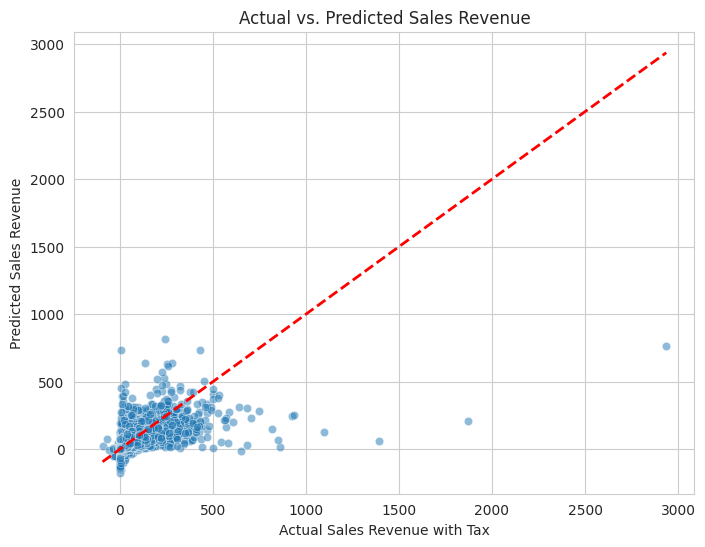

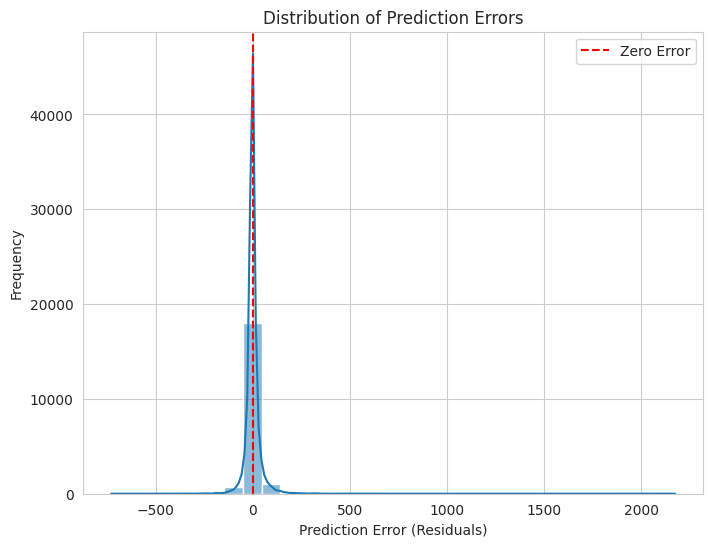

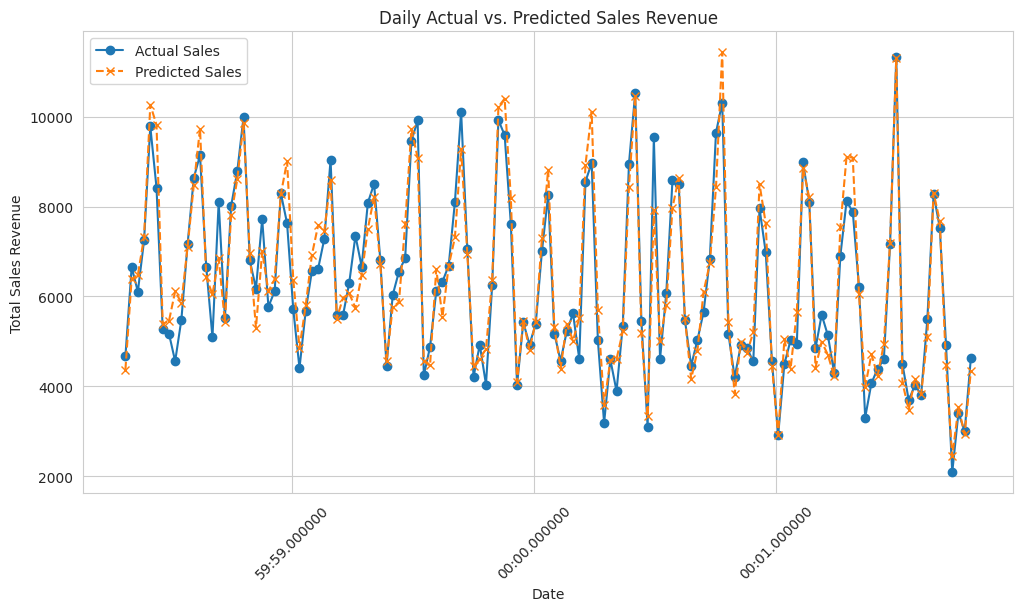

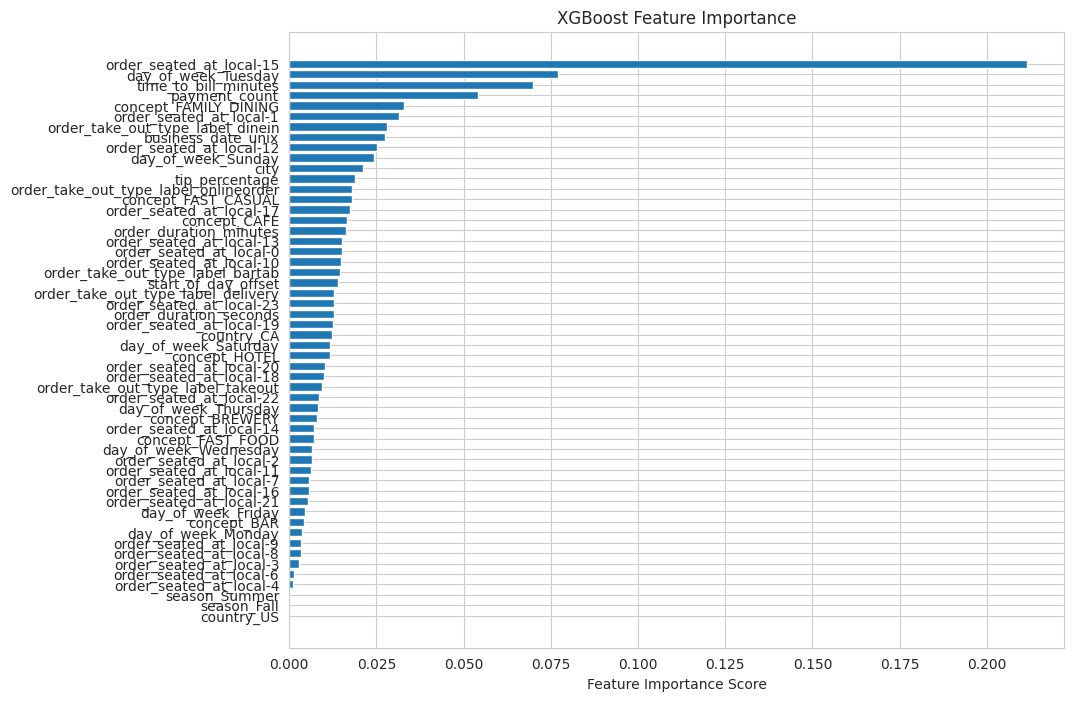

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# Set style for plots
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual Sales Revenue with Tax")
plt.ylabel("Predicted Sales Revenue")
plt.title("Actual vs. Predicted Sales Revenue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # 45-degree reference line
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(x=0, color='red', linestyle='--', label="Zero Error")
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales["actual_sales"], label="Actual Sales", marker='o')
plt.plot(daily_sales.index, daily_sales["predicted_sales"], label="Predicted Sales", marker='x', linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Total Sales Revenue")
plt.title("Daily Actual vs. Predicted Sales Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Ensure you're using the exact columns the model was trained on:
feature_importance = best_model.feature_importances_
feature_names = X_train_for_model.columns  # <-- Use this exact set of columns

# Sort importance
sorted_idx = np.argsort(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10, 8))
plt.barh(feature_names[sorted_idx], feature_importance[sorted_idx])
plt.xlabel("Feature Importance Score")
plt.title("XGBoost Feature Importance")
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Avoid division by zero in MAPE
nonzero_mask = y_test != 0  # Filter out zero values
mape = np.mean(np.abs((y_test[nonzero_mask] - y_pred[nonzero_mask]) / y_test[nonzero_mask])) * 100

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

df_copy = df.copy(deep=True)

# Sort Data by venue and time-based column
df_copy = df_copy.sort_values(by=["venue_xref_id", "business_date_unix"]).reset_index(drop=True)
df_copy['sales_revenue_with_tax'] = df_copy['sales_revenue_with_tax'].clip(lower=0)  # Replaces negatives with 0

target = "sales_revenue_with_tax"
features = [col for col in df_copy.columns if col != target]

scaler = StandardScaler()
df_copy[features] = scaler.fit_transform(df_copy[features])

df_copy[target] = df_copy[target].clip(lower=0)
target_scaler = StandardScaler()  # Keep a separate scaler for target variable
df_copy[target] = target_scaler.fit_transform(df_copy[[target]])

def create_sequences(data, seq_length):
    Xs, ys = [], []
    for i in range(len(data) - seq_length):
        Xs.append(data[i:i+seq_length, :-1])  # All features except target
        ys.append(data[i + seq_length, -1])  # Target value (sales_revenue_with_tax)
    return np.array(Xs), np.array(ys)

seq_length = 7

data_array = df_copy[features + [target]].values

X, y = create_sequences(data_array, seq_length)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

train_size = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

batch_size = 32
train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(list(zip(X_test, y_test)), batch_size=batch_size, shuffle=False)


class SalesLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(SalesLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Take last timestep output
        return out

input_size = len(features)  # Number of input features
hidden_size = 128
num_layers = 3
output_size = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SalesLSTM(input_size, hidden_size, num_layers, output_size).to(device)

criterion = nn.SmoothL1Loss()  # More stable for small loss values
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)  # Increased from 0.001


num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch).squeeze()
        loss = criterion(y_pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss / len(train_loader):.6f}")


KeyError: 'venue_xref_id'

Problem 4 - Effect of Operational Offsets on Sales

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Assume preprocessed DataFrame `df` is available
print(df.head())  # Check structure

# Convert business_date to datetime format
df["business_date"] = pd.to_datetime(df["business_date"])

# Aggregate daily metrics per venue
daily_sales = df.groupby(["business_date", "venue_xref_id"], as_index=False).agg({
    "start_of_day_offset": "first",  # Offset is the same per venue per day
    "bill_total_net": "sum",
    "bill_total_billed": "sum",
    "payment_total_tip": "sum"
})

# Calculate total order volume (approximated as count of transactions per day)
daily_sales["order_volume"] = df.groupby(["business_date", "venue_xref_id"])["bill_total_net"].count().values

Correlation Analysis

In [ ]:
corr_matrix = daily_sales[["start_of_day_offset", "bill_total_net", "bill_total_billed", "payment_total_tip", "order_volume"]].corr()
print("📊 Correlation Matrix:\n", corr_matrix)

# Pearson correlation coefficients
offset_corr_sales, _ = pearsonr(daily_sales["start_of_day_offset"], daily_sales["bill_total_net"])
offset_corr_tips, _ = pearsonr(daily_sales["start_of_day_offset"], daily_sales["payment_total_tip"])
offset_corr_orders, _ = pearsonr(daily_sales["start_of_day_offset"], daily_sales["order_volume"])

print(f"➡️ Correlation (Offset vs Net Sales): {offset_corr_sales:.2f}")
print(f"➡️ Correlation (Offset vs Tips): {offset_corr_tips:.2f}")
print(f"➡️ Correlation (Offset vs Order Volume): {offset_corr_orders:.2f}")

NameError: name 'daily_sales' is not defined

Visualization

In [ ]:
plt.figure(figsize=(12, 5))

# Scatter plot: Start_of_day_offset vs Net Sales
plt.subplot(1, 3, 1)
sns.scatterplot(x=daily_sales["start_of_day_offset"], y=daily_sales["bill_total_net"], alpha=0.5)
plt.xlabel("Start of Day Offset")
plt.ylabel("Total Net Sales")
plt.title("Offset vs Net Sales")

# Scatter plot: Start_of_day_offset vs Tips
plt.subplot(1, 3, 2)
sns.scatterplot(x=daily_sales["start_of_day_offset"], y=daily_sales["payment_total_tip"], alpha=0.5)
plt.xlabel("Start of Day Offset")
plt.ylabel("Total Tips")
plt.title("Offset vs Tips")

# Scatter plot: Start_of_day_offset vs Order Volume
plt.subplot(1, 3, 3)
sns.scatterplot(x=daily_sales["start_of_day_offset"], y=daily_sales["order_volume"], alpha=0.5)
plt.xlabel("Start of Day Offset")
plt.ylabel("Order Volume")
plt.title("Offset vs Order Volume")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

Heatmap of Correlations

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

NameError: name 'corr_matrix' is not defined

<Figure size 800x600 with 0 Axes>